In [85]:
import os
import datetime as dt

import pandas as pd
from pybit.unified_trading import HTTP
from dotenv import load_dotenv
import numpy as np
import scipy.stats as stats
from scipy.stats import shapiro, normaltest, jarque_bera, boxcox, yeojohnson
from statsmodels.stats.weightstats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [86]:
class BybitProvider:

    def __init__(self, testnet=True, api_key='', api_secret=''):
        self.testnet = testnet
        self.api_key = api_key
        self.api_secret = api_secret
        pass

    def get_data(self, symbol='BTCUSDT', interval=5, category='linear', start=None, end=None):
        df = pd.DataFrame()

        if start is not None:
            if not isinstance(start, dt.datetime):
                raise TypeError('Start date must be a datetime instance or None')

        if end is not None:
            if not isinstance(end, dt.datetime):
                raise TypeError('End date must be a datetime instance or None')

        if start and end:

            first_value_ts = None
            end_ts = int(end.timestamp() * 1000)
            while first_value_ts is None or int(start.timestamp() * 1000) < first_value_ts:
                frame = self.get_data_part(symbol=symbol, interval=interval, category=category,
                                           start=int(start.timestamp() * 1000), end=end_ts)

                df = pd.concat([frame, df])
                first_value_ts = int(df.index.values.astype(int)[0] / 1000000)
                end_ts = first_value_ts

            df = df.drop_duplicates()

        elif start and not end:
            df = self.get_data_part(symbol=symbol, interval=interval, category=category,
                                    start=int(start.timestamp() * 1000))
        elif not start and end:
            df = self.get_data_part(symbol=symbol, interval=interval, category=category,
                                    end=int(end.timestamp() * 1000))
        else:
            df = self.get_data_part(symbol=symbol, interval=interval, category=category)

        return df

    def get_data_part(self, symbol='BTCUSDT', interval=5, category='linear', start=None, end=None):
        session = HTTP(
            testnet=self.testnet,
            api_key=self.api_key,
            api_secret=self.api_secret,
        )

        response = session.get_kline(
            category=category,
            symbol=symbol,
            start=start,
            end=end,
            interval=interval).get('result')

        data = response.get('list', None)

        df_pybit = pd.DataFrame(data, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'Turnover'])

        datetime = pd.to_datetime(df_pybit['Timestamp'], unit='ms').dt.tz_localize('UTC')
        df_pybit.insert(loc=0, column='Datetime', value=datetime)
        df_pybit.drop(columns=['Turnover', 'Timestamp'], inplace=True)

        df_pybit["Open"] = pd.to_numeric(df_pybit["Open"])
        df_pybit["High"] = pd.to_numeric(df_pybit["High"])
        df_pybit["Low"] = pd.to_numeric(df_pybit["Low"])
        df_pybit["Close"] = pd.to_numeric(df_pybit["Close"])
        df_pybit["Volume"] = pd.to_numeric(df_pybit["Volume"])

        df_pybit.reindex(index=df_pybit.index[::-1])
        df_pybit = df_pybit.iloc[::-1]
        df_pybit = df_pybit.set_index('Datetime')
        return df_pybit


In [87]:
load_dotenv()
testnet = False
api_key = os.getenv('API_KEY')
api_secret = os.getenv('API_SECRET')

timeframe = '60'
currency = 'BTCUSDT'

start = dt.datetime(2022, 1, 1, tzinfo=dt.timezone.utc)
start = start - dt.timedelta(hours=200)
# end = dt.datetime(2025, 10, dt.datetime.now().day, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 9, tzinfo=dt.timezone.utc)

dataframe_filename = f'{currency}_{timeframe}_{start.strftime("%Y%m%d%H%M")}_{end.strftime("%Y%m%d%H%M")}.csv'
if not os.path.exists(dataframe_filename):
    provider = BybitProvider(testnet=testnet, api_key=api_key, api_secret=api_secret)
    df = provider.get_data(symbol=currency, interval=timeframe, start=start, end=end)
    df.reset_index(inplace=True)
    df.to_csv(dataframe_filename, sep="\t", index=False)
else:
    df = pd.read_csv(dataframe_filename, sep="\t")

In [88]:
df.head()

,Datetime,Open,High,Low,Close,Volume
0,2021-12-23 16:00:00+00:00,48780.0,49209.5,48654.0,49071.5,3149.583
1,2021-12-23 17:00:00+00:00,49071.5,50168.0,48951.0,50050.5,5399.727
2,2021-12-23 18:00:00+00:00,50050.5,50745.0,50050.0,50553.0,4752.739
3,2021-12-23 19:00:00+00:00,50553.0,51431.5,50480.0,51077.5,4015.635
4,2021-12-23 20:00:00+00:00,51077.5,51141.5,50639.0,50906.0,2217.734


# EDA

In [89]:
df.index

RangeIndex(start=0, stop=33249, step=1)

In [90]:
df.columns

Index(['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [91]:
df.describe()

,Open,High,Low,Close,Volume
count,33249.000000,33249.000000,33249.000000,33249.000000,33249.000000
mean,53559.283407,53748.688640,53365.975804,53561.508677,5170.377719
std,31350.362615,31439.411887,31261.200599,31352.649144,6393.885755
min,15632.500000,15763.000000,15440.000000,15632.500000,160.843000
25%,26904.800000,26978.800000,26850.100000,26904.800000,1800.157000
50%,42704.400000,42835.000000,42558.000000,42704.400000,3174.816000
75%,71037.200000,71269.000000,70789.100000,71039.000000,6087.545000
max,125981.300000,126150.000000,125151.900000,125981.300000,170105.791000


- count: количество записей
- mean: среднее значение
- std: стандартное отклонение
- min: минимальное значение
- 25%: 25й перцентиль (первый квартиль)
- 50%: 50й перцентиль (медиана)
- 75%: 75й перцентиль (третий квартиль)
- max: максимальное значение

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33249 entries, 0 to 33248
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  33249 non-null  object 
 1   Open      33249 non-null  float64
 2   High      33249 non-null  float64
 3   Low       33249 non-null  float64
 4   Close     33249 non-null  float64
 5   Volume    33249 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.5+ MB


Тип данных всех числовых значений: float64

In [93]:
df.isnull().sum()

Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
dtype: int64

Пустые значения отсутствуют

In [94]:
min_date = pd.to_datetime(df['Datetime'].min())
max_date = pd.to_datetime(df['Datetime'].max())
time_diff = max_date - min_date
hours = (time_diff.total_seconds() / 3600) + 1
hours

33249.0

Пропуски отсутствуют

# Аномалии

Z-score

Будем искать аномалии не в ценах закрытия напрямую, а в их логарифмических доходностях, иначе

In [95]:
from scipy.stats import zscore


def detect_anomalies_z(df, column):
    df_copy = df.copy()
    df_copy['Z-score'] = zscore(df_copy[column])
    anomalies = df_copy[abs(df_copy['Z-score']) > 1.5]
    return anomalies

In [96]:
# Рассчитываем часовую доходность (логарифмическую)
returns = df.copy()
returns.set_index(pd.to_datetime(returns['Datetime']), inplace=True)
returns['Close_Log'] = np.log(returns['Close'] / returns['Close'].shift(1))
returns['Volume_Log'] = np.log(returns['Volume'] / returns['Volume'].shift(1))
returns = returns.dropna()

returns.describe()

,Open,High,Low,Close,Volume,Close_Log,Volume_Log
count,33248.000000,33248.000000,33248.000000,33248.000000,33248.000000,33248.000000,33248.000000
mean,53559.427154,53748.825165,53366.117526,53561.643723,5170.438498,0.000028,-0.000016
std,31350.823131,31439.874843,31261.660050,31353.110981,6393.972306,0.005539,0.664345
min,15632.500000,15763.000000,15440.000000,15632.500000,160.843000,-0.073097,-2.568367
25%,26904.725000,26978.775000,26850.100000,26904.725000,1800.110000,-0.002036,-0.450476
50%,42704.250000,42835.000000,42557.000000,42704.250000,3175.498000,0.000043,-0.059162
75%,71037.650000,71270.250000,70789.425000,71039.675000,6087.548250,0.002162,0.380184
max,125981.300000,126150.000000,125151.900000,125981.300000,170105.791000,0.063404,3.758331


In [97]:
anomalies_adj_close = pd.DataFrame()
anomalies_volume = pd.DataFrame()

adj_close_anomalies = detect_anomalies_z(returns, 'Close_Log')
volume_anomalies = detect_anomalies_z(returns, 'Volume_Log')

anomalies_adj_close = pd.concat([anomalies_adj_close, adj_close_anomalies])
anomalies_volume = pd.concat([anomalies_volume, volume_anomalies])

anomalies_adj_close.head()

,Datetime,Open,High,Low,Close,Volume,Close_Log,Volume_Log,Z-score
Datetime,,,,,,,,,
2021-12-23 17:00:00+00:00,2021-12-23 17:00:00+00:00,49071.5,50168.0,48951.0,50050.5,5399.727,0.019754,0.539078,3.561478
2021-12-23 18:00:00+00:00,2021-12-23 18:00:00+00:00,50050.5,50745.0,50050.0,50553.0,4752.739,0.009990,-0.127627,1.798606
2021-12-23 19:00:00+00:00,2021-12-23 19:00:00+00:00,50553.0,51431.5,50480.0,51077.5,4015.635,0.010322,-0.168526,1.858547
2021-12-24 18:00:00+00:00,2021-12-24 18:00:00+00:00,51073.0,51980.0,51061.0,51580.0,2661.339,0.009878,1.179907,1.778426
2021-12-24 19:00:00+00:00,2021-12-24 19:00:00+00:00,51580.0,51825.5,51060.0,51100.0,2231.979,-0.009350,-0.175941,-1.692965


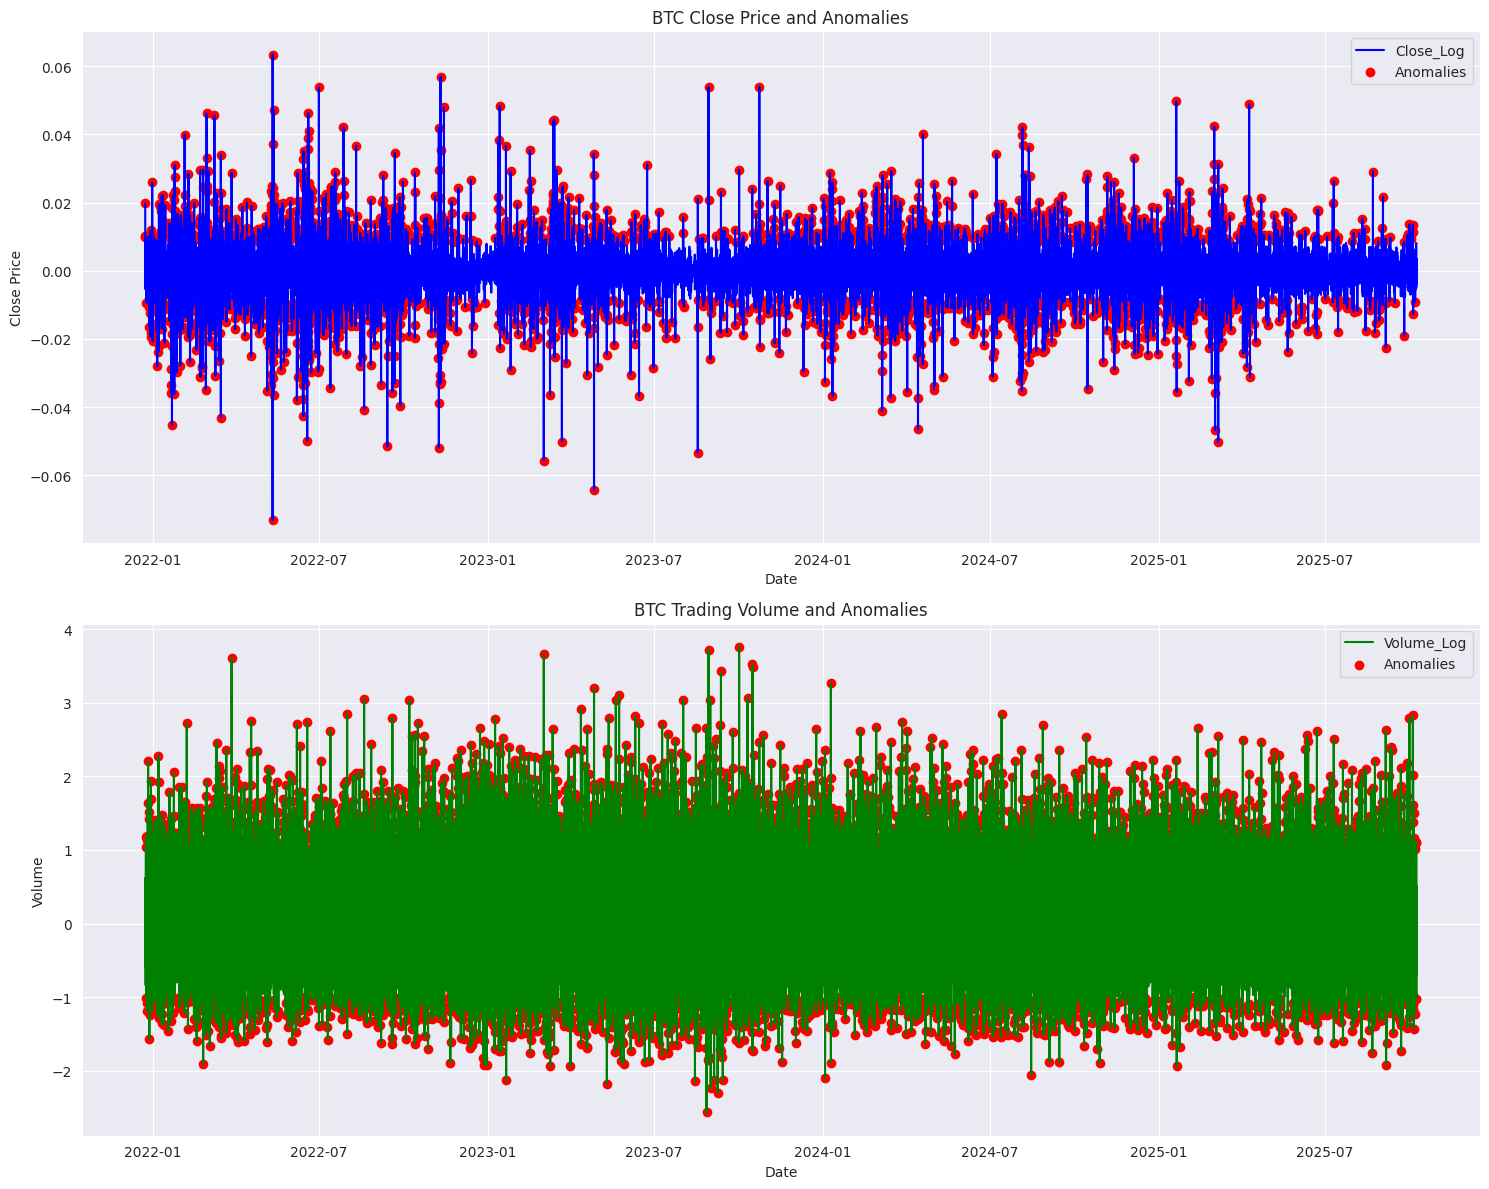

In [98]:
import matplotlib.pyplot as plt


# функция для визуализации
def plot_anomalies(ticker, anomalies_adj_close, anomalies_volume):
    data_ticker = returns
    adj_close_anomalies = anomalies_adj_close
    volume_anomalies = anomalies_volume

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    ax1.plot(data_ticker.index, data_ticker['Close_Log'], label='Close_Log', color='blue')
    ax1.scatter(adj_close_anomalies.index, adj_close_anomalies['Close_Log'], color='red', label='Anomalies')
    ax1.set_title(f'{ticker} Close Price and Anomalies')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price')
    ax1.legend()

    ax2.plot(data_ticker.index, data_ticker['Volume_Log'], label='Volume_Log', color='green')
    ax2.scatter(volume_anomalies.index, volume_anomalies['Volume_Log'], color='red', label='Anomalies')
    ax2.set_title(f'{ticker} Trading Volume and Anomalies')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Volume')
    ax2.legend()

    plt.tight_layout()
    plt.show()


plot_anomalies('BTC', anomalies_adj_close, anomalies_volume)

Распределения доходности по Close и Volume

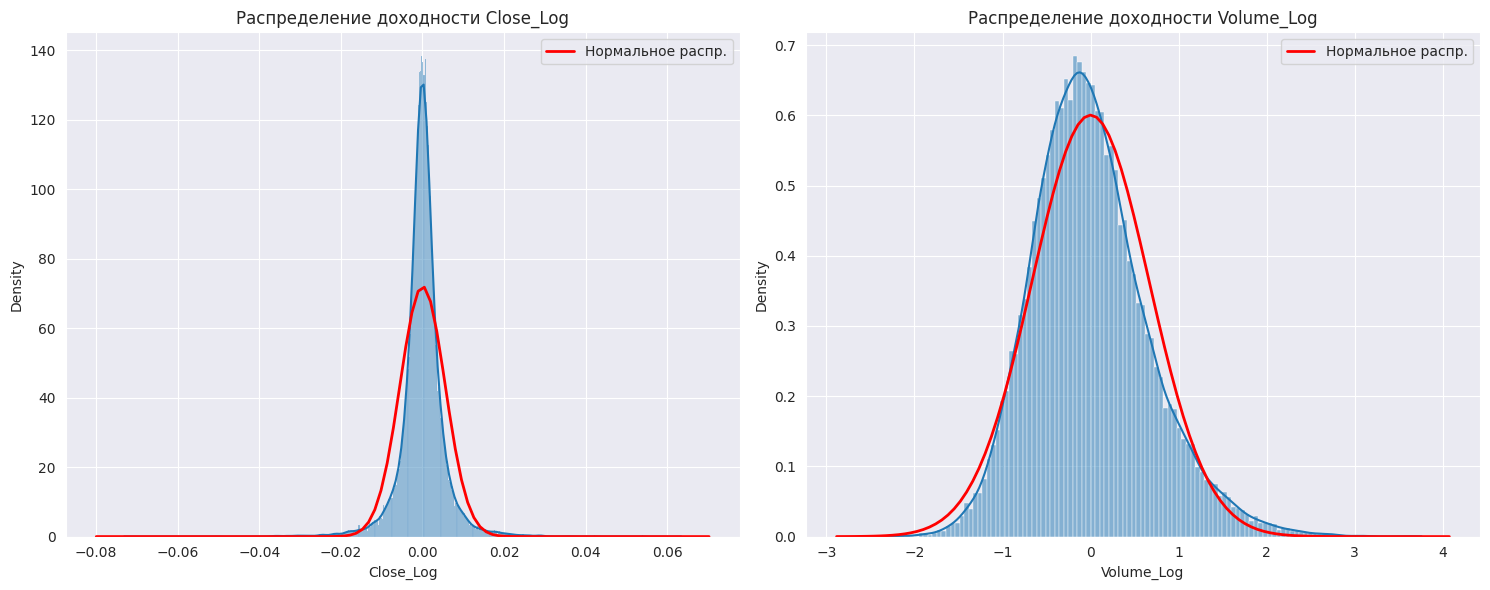

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(['Close_Log', 'Volume_Log']):
    sns.histplot(returns[col], kde=True, ax=axes[i], stat='density')
    axes[i].set_title(f'Распределение доходности {col}')
    # Добавляем линию нормального распределения с теми же параметрами
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, returns[col].mean(), returns[col].std())
    axes[i].plot(x, p, 'r', linewidth=2, label='Нормальное распр.')
    axes[i].legend()

plt.tight_layout()
plt.show()

Проверка на нормальность и преобразование данных

In [100]:
def check_normality(data, alpha=0.05):
    """Проверяет распределение на нормальность с помощью нескольких тестов"""
    tests = {
        'Shapiro-Wilk': shapiro,
        'D\'Agostino': normaltest,
        'Jarque-Bera': jarque_bera
    }

    results = {}
    for name, test_func in tests.items():
        stat, p_value = test_func(data)
        results[name] = {'Statistic': stat, 'p-value': p_value, 'Normal': p_value > alpha}

    return pd.DataFrame(results)


print("Проверка на нормальность для BTCUSDT Close:")
print(check_normality(returns['Close_Log']))

print("\nПроверка на нормальность для BTCUSDT Volume:")
print(check_normality(returns['Volume_Log']))

Проверка на нормальность для BTCUSDT Close:
          Shapiro-Wilk  D'Agostino    Jarque-Bera
Statistic     0.851143  7052.64441  274700.896509
p-value            0.0         0.0            0.0
Normal           False       False          False

Проверка на нормальность для BTCUSDT Volume:
          Shapiro-Wilk   D'Agostino Jarque-Bera
Statistic     0.981921  2201.241663   3025.0555
p-value            0.0          0.0         0.0
Normal           False        False       False


Преобразования Бокса-Кокса

In [101]:
# Сдвигаем доходности, чтобы сделать их положительными
close_shifted = returns['Close_Log'] - returns['Close_Log'].min() + 1e-6
volume_shifted = returns['Volume_Log'] - returns['Volume_Log'].min() + 1e-6

# Применяем преобразование Бокса-Кокса
close_boxcox, lambda_close = boxcox(close_shifted)
volume_boxcox, lambda_volume = boxcox(volume_shifted)

print(f"Оптимальные лямбда для BTCUSDT Close: {lambda_close:.4f}")
print(f"Оптимальные лямбда для BTCUSDT Volume: {lambda_volume:.4f}")

# Проверяем нормальность после преобразования
print("\nПроверка нормальности после Бокса-Кокса для BTCUSDT Close:")
print(check_normality(close_boxcox))

Оптимальные лямбда для BTCUSDT Close: 1.3338
Оптимальные лямбда для BTCUSDT Volume: 0.4442

Проверка нормальности после Бокса-Кокса для BTCUSDT Close:
          Shapiro-Wilk   D'Agostino    Jarque-Bera
Statistic     0.853732  7941.039613  265751.052702
p-value            0.0          0.0            0.0
Normal           False        False          False


Бокса-Кокс не помог (или данные содержат отрицательные значения), пробуем Йео-Джонсона:

Оптимальные лямбда Йео-Джонсона для BTCUSDT Close: 2.5268
Оптимальные лямбда Йео-Джонсона для BTCUSDT Volume: 0.6247

Проверка нормальности после Йео-Джонсона для BTCUSDT Close:
          Shapiro-Wilk   D'Agostino    Jarque-Bera
Statistic     0.851391  6911.223967  273349.335189
p-value            0.0          0.0            0.0
Normal           False        False          False


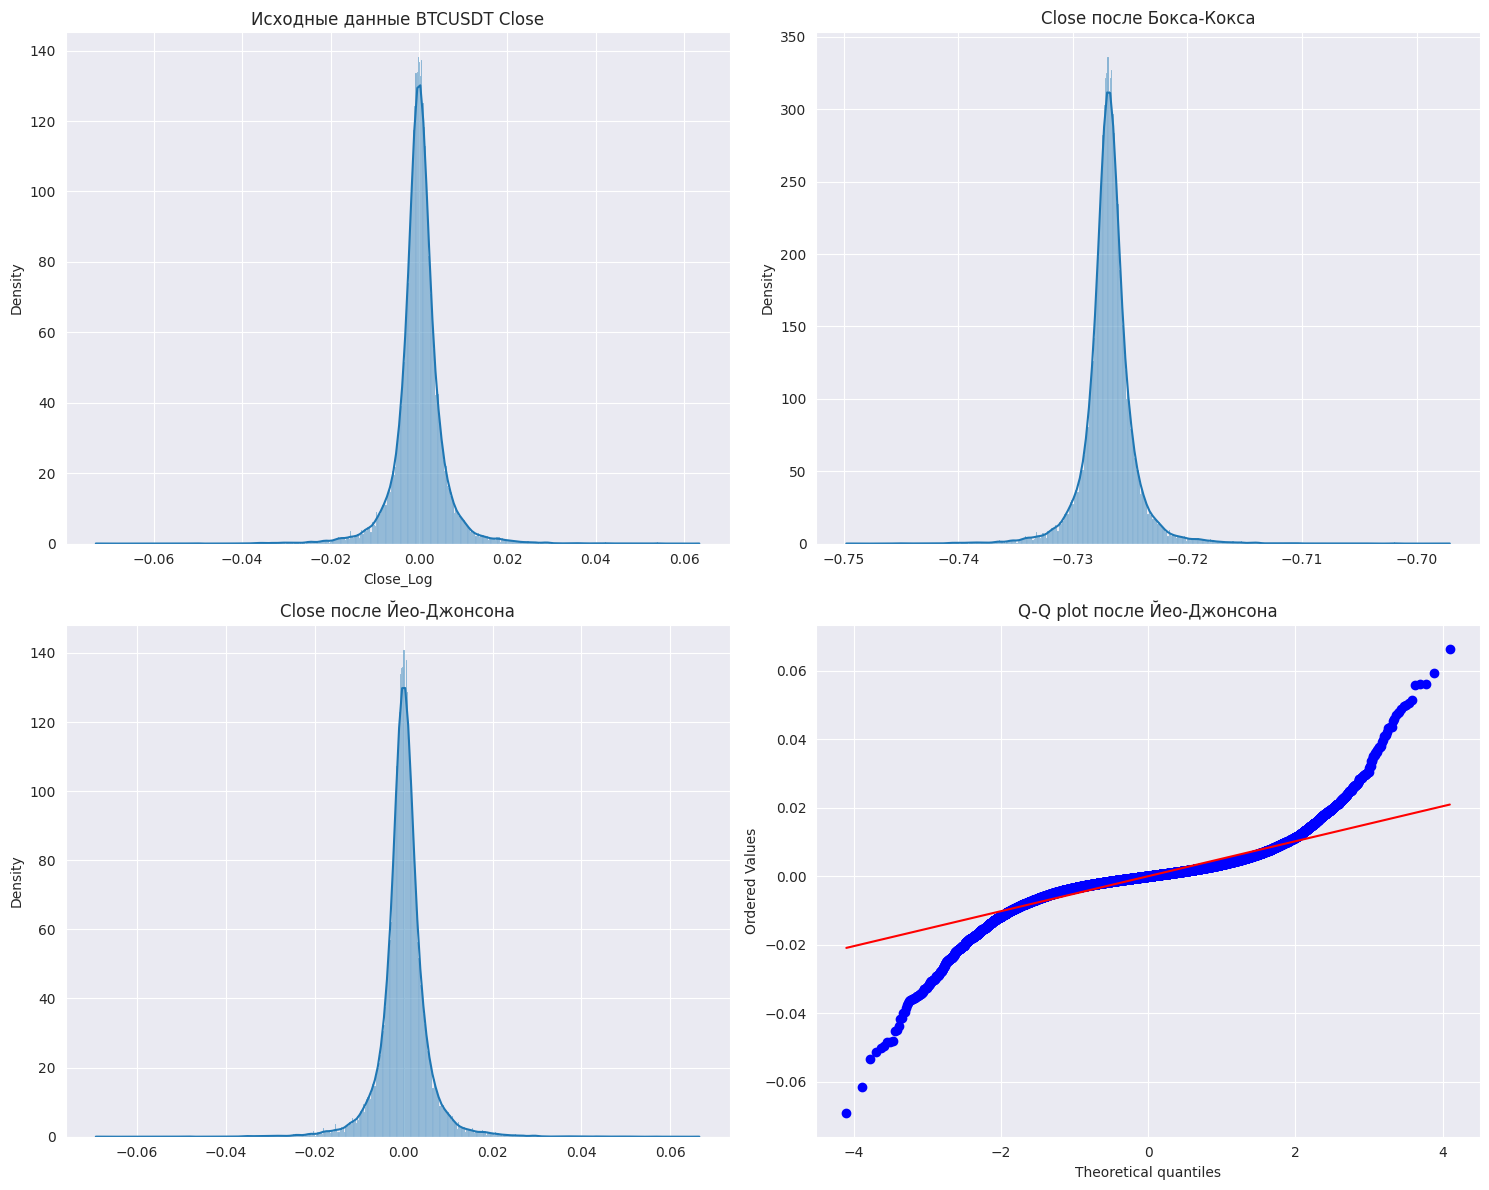

In [102]:
close_yeojohnson, lambda_close_yj = yeojohnson(returns['Close_Log'])
volume_yeojohnson, lambda_volume_yj = yeojohnson(returns['Volume_Log'])

print(f"Оптимальные лямбда Йео-Джонсона для BTCUSDT Close: {lambda_close_yj:.4f}")
print(f"Оптимальные лямбда Йео-Джонсона для BTCUSDT Volume: {lambda_volume_yj:.4f}")

# Проверяем нормальность после преобразования
print("\nПроверка нормальности после Йео-Джонсона для BTCUSDT Close:")
print(check_normality(close_yeojohnson))

# Визуализируем преобразованные данные
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Исходные данные
sns.histplot(returns['Close_Log'], kde=True, ax=axes[0, 0], stat='density')
axes[0, 0].set_title('Исходные данные BTCUSDT Close')

sns.histplot(close_boxcox, kde=True, ax=axes[0, 1], stat='density')
axes[0, 1].set_title('Close после Бокса-Кокса')

sns.histplot(close_yeojohnson, kde=True, ax=axes[1, 0], stat='density')
axes[1, 0].set_title('Close после Йео-Джонсона')

# Q-Q plot для проверки нормальности
stats.probplot(close_yeojohnson, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot после Йео-Джонсона')

plt.tight_layout()
plt.show()

Анализ выбросов и оценка их статистической значимости

Выбросы BTCUSDT Close: 2875 наблюдений
Границы: [-0.0083, 0.0085]


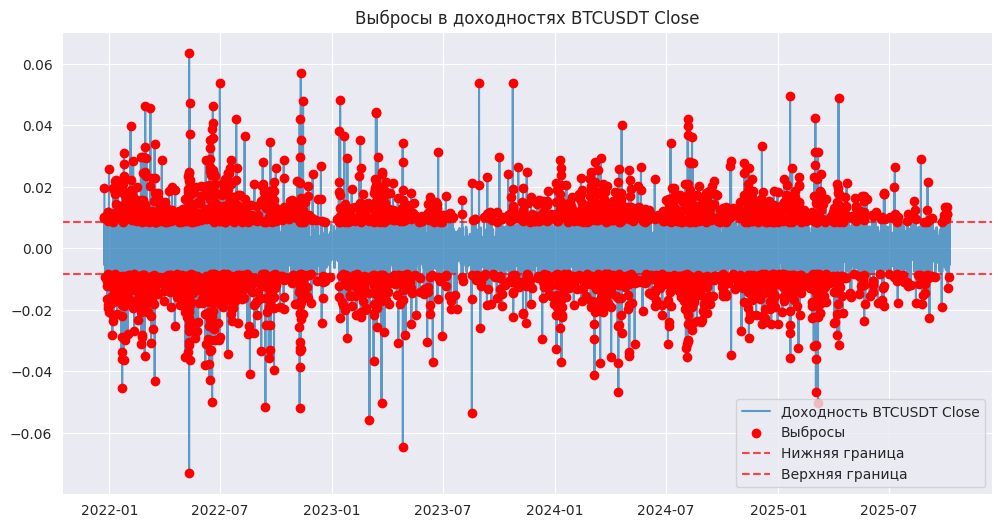

In [103]:
def detect_outliers_iqr(data, column):
    """Обнаружение выбросов с помощью метода IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


# Детектируем выбросы для Close
close_outliers, lower, upper = detect_outliers_iqr(returns, 'Close_Log')
print(f"Выбросы BTCUSDT Close: {len(close_outliers)} наблюдений")
print(f"Границы: [{lower:.4f}, {upper:.4f}]")

# Визуализация выбросов
plt.figure(figsize=(12, 6))
plt.plot(returns.index, returns['Close_Log'], label='Доходность BTCUSDT Close', alpha=0.7)
plt.scatter(close_outliers.index, close_outliers['Close_Log'], color='red', label='Выбросы', zorder=5)
plt.axhline(y=lower, color='r', linestyle='--', alpha=0.7, label='Нижняя граница')
plt.axhline(y=upper, color='r', linestyle='--', alpha=0.7, label='Верхняя граница')
plt.legend()
plt.title('Выбросы в доходностях BTCUSDT Close')
plt.show()

In [104]:
# !pip install outlier-utils

In [105]:
from outliers import smirnov_grubbs as grubbs


def grubbs_test_outliers(data):
    """Тест Граббса на выбросы"""
    try:
        outliers = grubbs.max_test_outliers(data, alpha=0.05)
        return outliers
    except:
        return []


# Применяем тест Граббса
close_grubbs_outliers = grubbs_test_outliers(returns['Close_Log'].values)
print(f"Статистически значимые выбросы (тест Граббса): {len(close_grubbs_outliers)}")

# Анализ дат выбросов
if len(close_grubbs_outliers) > 0:
    for value in close_grubbs_outliers:
        row = returns[returns['Close_Log'] == value]
        print(f"{row['Datetime'].values[0]}: {row['Close_Log'].values[0]:.4f}")

Статистически значимые выбросы (тест Граббса): 104
2022-05-11 13:00:00+00:00: 0.0634
2022-11-10 13:00:00+00:00: 0.0570
2023-10-23 22:00:00+00:00: 0.0539
2023-08-29 14:00:00+00:00: 0.0539
2022-06-30 23:00:00+00:00: 0.0538
2025-01-20 06:00:00+00:00: 0.0497
2025-04-09 17:00:00+00:00: 0.0488
2023-01-14 00:00:00+00:00: 0.0483
2022-11-14 06:00:00+00:00: 0.0479
2022-05-12 14:00:00+00:00: 0.0473
2022-06-19 10:00:00+00:00: 0.0463
2022-02-28 14:00:00+00:00: 0.0461
2022-03-09 03:00:00+00:00: 0.0456
2023-03-14 12:00:00+00:00: 0.0443
2023-03-13 14:00:00+00:00: 0.0439
2025-03-02 16:00:00+00:00: 0.0424
2022-07-27 18:00:00+00:00: 0.0422
2024-08-05 13:00:00+00:00: 0.0421
2022-11-08 16:00:00+00:00: 0.0420
2022-06-19 18:00:00+00:00: 0.0409
2024-04-19 06:00:00+00:00: 0.0400
2022-02-04 15:00:00+00:00: 0.0399
2024-08-05 14:00:00+00:00: 0.0397
2022-06-18 21:00:00+00:00: 0.0388
2023-01-12 17:00:00+00:00: 0.0382
2022-05-12 07:00:00+00:00: 0.0371
2024-08-06 00:00:00+00:00: 0.0368
2023-01-20 20:00:00+00:00: 0.03

Задача 1: Проверить гипотезу о равенстве средних доходностей (t-тест).

In [106]:
# T-тест для независимых выборок
t_stat, p_value, df = ttest_ind(
    returns['Close_Log'],
    returns['Volume_Log'],
    alternative='two-sided'
)

print("T-тест на равенство средних доходностей:")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Степени свободы: {df}")

if p_value < 0.05:
    print("Отвергаем H0: Средние доходности статистически значимо различаются")
else:
    print("Не отвергаем H0: Нет доказательств различия средних доходностей")

T-тест на равенство средних доходностей:
t-статистика: 0.0120
p-value: 0.9904
Степени свободы: 66494.0
Не отвергаем H0: Нет доказательств различия средних доходностей


Задача 2: Проверить гипотезу о равенстве дисперсий (тест Левена).

In [107]:
from scipy.stats import levene

# Тест Левена на равенство дисперсий
levene_stat, levene_p = levene(returns['Close_Log'], returns['Volume_Log'])

print(f"\nТест Левена на равенство дисперсий:")
print(f"F-статистика: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

if levene_p < 0.05:
    print("Отвергаем H0: Дисперсии статистически значимо различаются")
else:
    print("Не отвергаем H0: Нет доказательств различия дисперсий")


Тест Левена на равенство дисперсий:
F-статистика: 47537.0127
p-value: 0.0000
Отвергаем H0: Дисперсии статистически значимо различаются
